In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load without recompiling to avoid legacy H5 loss/metric deserialization issues in Keras 3
autoencoder = load_model("../MODELS/autoencoder.h5", compile=False)

In [5]:
df = pd.read_csv("../PREPROCESSING/processed_cicids2017.csv")

In [6]:
X = df.drop(columns=['Label'])
y = df['Label']

X = X.values
y = y.values

In [7]:
X_pred = autoencoder.predict(X)

88372/88372 ━━━━━━━━━━━━━━━━━━━━ 32s 366us/step


In [8]:
mse = np.mean(np.power(X - X_pred, 2), axis=1)

In [9]:
error_df = pd.DataFrame({
    'reconstruction_error': mse,
    'true_label': y
})

In [10]:
benign_errors = error_df[error_df.true_label == 0]['reconstruction_error']

In [17]:
percentiles = [85, 90, 92, 95, 97, 99]

for p in percentiles:

    threshold = np.percentile(benign_errors, p)

    preds = (error_df.reconstruction_error > threshold).astype(int)

    print("\nThreshold percentile:", p)
    print("Threshold value:", threshold)

    print(confusion_matrix(error_df.true_label, preds))
    print(classification_report(error_df.true_label, preds))


Threshold percentile: 85
Threshold value: 0.30676909665801266
[[1930622  340698]
 [ 346137  210419]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85   2271320
           1       0.38      0.38      0.38    556556

    accuracy                           0.76   2827876
   macro avg       0.61      0.61      0.61   2827876
weighted avg       0.76      0.76      0.76   2827876


Threshold percentile: 90
Threshold value: 0.5122010696851462
[[2044188  227132]
 [ 403231  153325]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87   2271320
           1       0.40      0.28      0.33    556556

    accuracy                           0.78   2827876
   macro avg       0.62      0.59      0.60   2827876
weighted avg       0.75      0.78      0.76   2827876


Threshold percentile: 92
Threshold value: 0.5224141633096979
[[2089614  181706]
 [ 406674  149882]]
              precision    recall  f1-scor

In [19]:
best_percentile = 85
threshold = np.percentile(benign_errors, best_percentile)

error_df["prediction"] = (error_df.reconstruction_error > threshold).astype(int)

print("Final Threshold:", threshold)

print(confusion_matrix(error_df.true_label, error_df.prediction))
print(classification_report(error_df.true_label, error_df.prediction))

Final Threshold: 0.30676909665801266
[[1930622  340698]
 [ 346137  210419]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85   2271320
           1       0.38      0.38      0.38    556556

    accuracy                           0.76   2827876
   macro avg       0.61      0.61      0.61   2827876
weighted avg       0.76      0.76      0.76   2827876



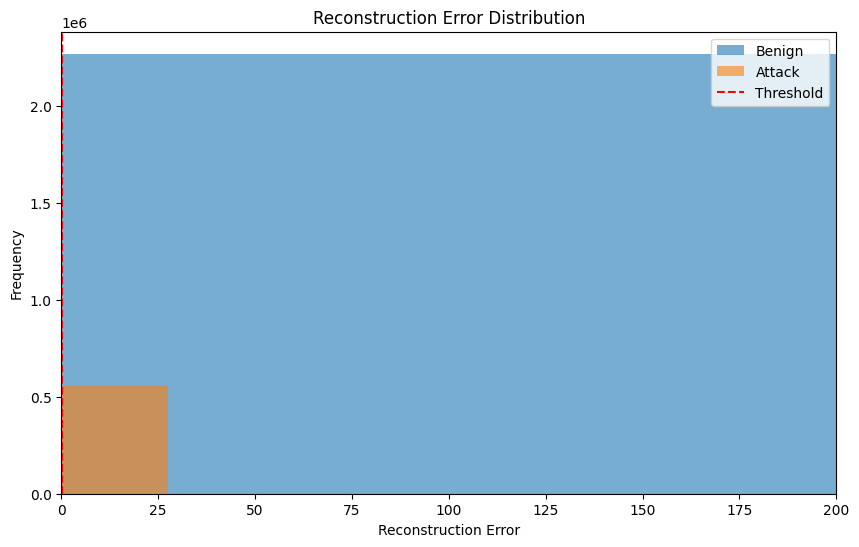

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    error_df[error_df.true_label == 0].reconstruction_error,
    bins=50,
    alpha=0.6,
    label="Benign"
)

plt.hist(
    error_df[error_df.true_label == 1].reconstruction_error,
    bins=50,
    alpha=0.6,
    label="Attack"
)

plt.axvline(threshold, color='red', linestyle='--', label="Threshold")

plt.xlim(0,200)

plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.show()